In [57]:
%pip install SimpleITK opencv-python matplotlib wandb

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [58]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import SimpleITK as sitk
import cv2
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
import wandb

# 1. Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {device}")
if torch.cuda.is_available():
    print(f"🚀 GPU Name: {torch.cuda.get_device_name(0)}")

# 2. Paths
base_path = 'database/'
all_patients = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
all_patients.sort()

# 3. Data Split (Fixed: 400 Train, 50 Val, 50 Test)
random.seed(42)
random.shuffle(all_patients)

# Ta7did el-indices nichan kima tlab l-encadreur
train_list = all_patients[:400]         # L-awlin 400 l-el-training
val_list   = all_patients[400:450]      # 50 li ba3dhom l-el-validation
test_list  = all_patients[450:500]      # 50 el-baqyin l-el-testing

print(f"✅ Data split fixed according to supervisor's request:")
print(f"   - Training:   {len(train_list)} patients")
print(f"   - Validation: {len(val_list)} patients")
print(f"   - Testing:    {len(test_list)} patients")

✅ Using device: cuda
🚀 GPU Name: NVIDIA GeForce RTX 3060 Laptop GPU
✅ Data split fixed according to supervisor's request:
   - Training:   400 patients
   - Validation: 50 patients
   - Testing:    50 patients


In [59]:
class CamusDataset(Dataset):
    def __init__(self, patient_list, base_path, target_size=(256, 256), augment=False):
        self.patient_list = patient_list
        self.base_path = base_path
        self.target_size = target_size
        self.augment = augment
        
        # N-diro lista fiha ga3 el-tsawer el-moumkina l-koul patient
        self.all_files = []
        for p_id in self.patient_list:
            for view in ["2CH", "4CH"]:
                for phase in ["ED", "ES"]:
                    self.all_files.append({
                        "id": p_id,
                        "view": view,   # Gardyha bach nasta3mloha fl-rsem
                        "phase": phase, # Gardyha bach nasta3mloha fl-rsem  
                        "img": f"{p_id}_{view}_{phase}.nii.gz",
                        "mask": f"{p_id}_{view}_{phase}_gt.nii.gz"
                    })

    def __len__(self):
        return len(self.all_files) # Dorka el-length rahi 400 * 4 = 1600

    def __getitem__(self, idx):
        file_info = self.all_files[idx]
        p_id = file_info["id"]
        
        img_path = os.path.join(self.base_path, p_id, file_info["img"])
        mask_path = os.path.join(self.base_path, p_id, file_info["mask"])

        # Reading & Normalization (Nfas el-concept)
        img = np.squeeze(sitk.GetArrayFromImage(sitk.ReadImage(img_path))).astype(np.float32)
        mask = np.squeeze(sitk.GetArrayFromImage(sitk.ReadImage(mask_path))).astype(np.float32)
        
        mask = (mask == 1).astype(np.float32) # Left Ventricle ghir
        
        img = cv2.resize(img, self.target_size, interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, self.target_size, interpolation=cv2.INTER_NEAREST)

        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        img_t = torch.from_numpy(img).unsqueeze(0).float()
        mask_t = torch.from_numpy(mask).long() 

        if self.augment:
            if random.random() > 0.5:
                img_t = TF.hflip(img_t)
                mask_t = TF.hflip(mask_t.unsqueeze(0)).squeeze(0)
            
            angle = random.uniform(-20, 20)
            img_t = TF.rotate(img_t, angle)
            mask_t = TF.rotate(mask_t.unsqueeze(0), angle).squeeze(0)
            
        view_name = f"{file_info['view']} {file_info['phase']}"
        return img_t, mask_t,view_name

# Update Loaders (400 train patients -> 1600 images)
train_ds = CamusDataset(train_list, base_path, augment=True)
val_ds = CamusDataset(val_list, base_path, augment=False)
test_ds = CamusDataset(test_list, base_path, augment=False) 

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True) # Zidna batch size chwiya
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False)

print(f"✅ Dataset updated: Training on {len(train_ds)} images (2CH/4CH ED/ES)")

✅ Dataset updated: Training on 1600 images (2CH/4CH ED/ES)


In [71]:
def double_conv(in_channels, out_channels):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True)
    )

class UNet(nn.Module):
    def __init__(self, n_classes=2):
        super(UNet, self).__init__()
        
        self.enc1 = double_conv(1, 64)
        self.enc2 = double_conv(64, 128)
        self.enc3 = double_conv(128, 256)
        self.enc4 = double_conv(256, 512)
        self.pool = nn.MaxPool2d(2)
        
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = double_conv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = double_conv(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = double_conv(128, 64)
        
        self.final = nn.Conv2d(64, n_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        
        d3 = self.up3(e4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)
        
        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)
        
        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)
        
        return self.final(d1)

# Model push to RTX 3060
model = UNet(n_classes=2).to(device)
print(f"✅ U-Net Model loaded on {device}")


✅ U-Net Model loaded on cuda


In [74]:
num_epochs = 50 # Dir 50 bach el-model yet3allem mlih
best_dice = 0.0

print(f"🚀 Starting Training for {num_epochs} epochs...")

for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    model.train()
    train_loss = 0.0
    for images, masks, _ in train_loader: # Zidna '_' bach n-fixou el-ValueError
        images, masks = images.to(device), masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()

    # --- VALIDATION PHASE ---
    model.eval()
    val_loss = 0.0
    total_dice = 0.0
    
    with torch.no_grad():
        for images, masks, _ in val_loader: # Zidna '_' hna tani
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            v_loss = criterion(outputs, masks)
            val_loss += v_loss.item()
            
            # 7isab el-Dice Score
            preds = torch.argmax(outputs, dim=1)
            # Dice logic simple: (2*Intersection)/(Sum)
            inter = (preds * masks).sum()
            union = preds.sum() + masks.sum()
            dice = (2. * inter + 1e-6) / (union + 1e-6)
            total_dice += dice.item()

    avg_train = train_loss / len(train_loader)
    avg_val = val_loss / len(val_loader)
    avg_dice = total_dice / len(val_loader)

    # Log to WandB
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": avg_train,
        "val_loss": avg_val,
        "dice_score": avg_dice
    })

    if (epoch + 1) % 1 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f} | Dice: {avg_dice:.4f}")

    # Save best model weights
    if avg_dice > best_dice:
        best_dice = avg_dice
        torch.save(model.state_dict(), 'unet_camus_best.pth')
        print(f"🌟 New Best Dice: {best_dice:.4f} (Model Saved)")

print(f"✅ Training Finished! Best Dice: {best_dice:.4f}")

🚀 Starting Training for 50 epochs...
Epoch [1/50] | Train Loss: 0.3045 | Val Loss: 0.2039 | Dice: 0.8367
🌟 New Best Dice: 0.8367 (Model Saved)
Epoch [2/50] | Train Loss: 0.1715 | Val Loss: 0.1342 | Dice: 0.8804
🌟 New Best Dice: 0.8804 (Model Saved)
Epoch [3/50] | Train Loss: 0.1255 | Val Loss: 0.1059 | Dice: 0.8846
🌟 New Best Dice: 0.8846 (Model Saved)
Epoch [4/50] | Train Loss: 0.1003 | Val Loss: 0.0899 | Dice: 0.8874
🌟 New Best Dice: 0.8874 (Model Saved)
Epoch [5/50] | Train Loss: 0.0848 | Val Loss: 0.0763 | Dice: 0.8973
🌟 New Best Dice: 0.8973 (Model Saved)
Epoch [6/50] | Train Loss: 0.0756 | Val Loss: 0.0638 | Dice: 0.9102
🌟 New Best Dice: 0.9102 (Model Saved)
Epoch [7/50] | Train Loss: 0.0696 | Val Loss: 0.0626 | Dice: 0.9082
Epoch [8/50] | Train Loss: 0.0646 | Val Loss: 0.0642 | Dice: 0.9042
Epoch [9/50] | Train Loss: 0.0602 | Val Loss: 0.0568 | Dice: 0.9122
🌟 New Best Dice: 0.9122 (Model Saved)
Epoch [10/50] | Train Loss: 0.0579 | Val Loss: 0.0570 | Dice: 0.9092
Epoch [11/50] | 

In [75]:
import matplotlib.pyplot as plt

def visualize_final_results(model, dataset, num_samples=3):
    model.eval()
    plt.figure(figsize=(18, 12))
    
    # Njbdou random samples mel-validation set
    indices = random.sample(range(len(dataset)), num_samples)
    
    for i, idx in enumerate(indices):
        img, mask, name = dataset[idx]
        img_input = img.unsqueeze(0).to(device)
        
        with torch.no_grad():
            pred = model(img_input)
            pred_mask = torch.argmax(pred, dim=1).cpu().squeeze(0)
        
        # 1. Original Image
        plt.subplot(num_samples, 3, i*3 + 1)
        plt.imshow(img.squeeze(), cmap='gray')
        plt.title(f"Input: {name}")
        plt.axis('off')
        
        # 2. Ground Truth
        plt.subplot(num_samples, 3, i*3 + 2)
        plt.imshow(mask, cmap='jet')
        plt.title("Ground Truth (Expert)")
        plt.axis('off')
        
        # 3. Model Prediction
        plt.subplot(num_samples, 3, i*3 + 3)
        plt.imshow(pred_mask, cmap='jet')
        plt.title(f"U-Net Prediction")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

# Run this only after epoch 50
# visualize_final_results(model, val_ds)

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


dice_score,▁▄▄▅▅▆▆▇▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇████▇█▇███▇█████
epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
train_loss,█▅▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▅▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁
dice_score,0.92945
epoch,50
train_loss,0.03425
val_loss,0.04084


Epoch 1 | Dice: 0.6747
Epoch 2 | Dice: 0.8845
Epoch 3 | Dice: 0.8789
Epoch 4 | Dice: 0.9051
Epoch 5 | Dice: 0.8900
Epoch 6 | Dice: 0.9177
Epoch 7 | Dice: 0.8926
Epoch 8 | Dice: 0.9171
Epoch 9 | Dice: 0.9190
Epoch 10 | Dice: 0.9244
Epoch 11 | Dice: 0.9120
Epoch 12 | Dice: 0.9199
Epoch 13 | Dice: 0.9233
Epoch 14 | Dice: 0.9233
Epoch 15 | Dice: 0.9250
Epoch 16 | Dice: 0.9264
Epoch 17 | Dice: 0.8961
Epoch 18 | Dice: 0.9212
Epoch 19 | Dice: 0.9264
Epoch 20 | Dice: 0.9284
Epoch 21 | Dice: 0.9305
Epoch 22 | Dice: 0.9264
Epoch 23 | Dice: 0.9308
Epoch 24 | Dice: 0.9328
Epoch 25 | Dice: 0.9337
Epoch 26 | Dice: 0.9312
Epoch 27 | Dice: 0.9327
Epoch 28 | Dice: 0.9329
Epoch 29 | Dice: 0.9317
Epoch 30 | Dice: 0.9240
Epoch 31 | Dice: 0.9283
Epoch 32 | Dice: 0.9359
Epoch 33 | Dice: 0.9360
Epoch 34 | Dice: 0.9358
Epoch 35 | Dice: 0.9359
Epoch 36 | Dice: 0.9330
Epoch 37 | Dice: 0.9332
Epoch 38 | Dice: 0.9359
Epoch 39 | Dice: 0.9382
Epoch 40 | Dice: 0.9366
Epoch 41 | Dice: 0.9287
Epoch 42 | Dice: 0.9368
E

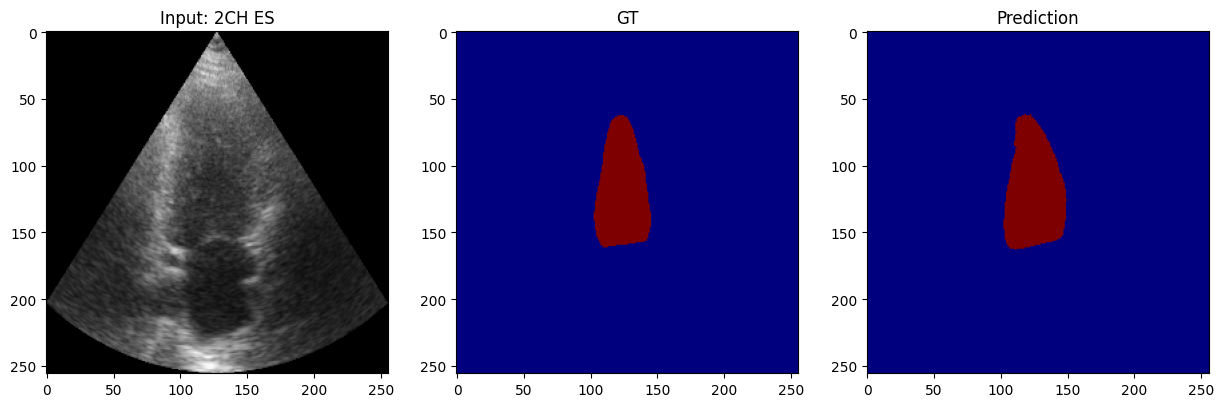

In [82]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import SimpleITK as sitk
import cv2
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
import wandb

# ==========================================
# 1. Configuration & Device
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.environ["WANDB_MODE"] = "offline" 
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# ==========================================
# 2. Dataset Class (Fixed for 3 outputs)
# ==========================================
class CamusDataset(Dataset):
    def __init__(self, patient_list, base_path, target_size=(256, 256), augment=False):
        self.patient_list = patient_list
        self.base_path = base_path
        self.target_size = target_size
        self.augment = augment
        self.all_files = []
        for p_id in self.patient_list:
            for view in ["2CH", "4CH"]:
                for phase in ["ED", "ES"]:
                    self.all_files.append({
                        "id": p_id, "view": view, "phase": phase,
                        "img": f"{p_id}_{view}_{phase}.nii.gz",
                        "mask": f"{p_id}_{view}_{phase}_gt.nii.gz"
                    })

    def __len__(self): return len(self.all_files)

    def __getitem__(self, idx):
        file_info = self.all_files[idx]
        p_id = file_info["id"]
        img_path = os.path.join(self.base_path, p_id, file_info["img"])
        mask_path = os.path.join(self.base_path, p_id, file_info["mask"])

        img = np.squeeze(sitk.GetArrayFromImage(sitk.ReadImage(img_path))).astype(np.float32)
        mask = np.squeeze(sitk.GetArrayFromImage(sitk.ReadImage(mask_path))).astype(np.float32)
        
        mask = (mask == 1).astype(np.float32) # LV focus
        img = cv2.resize(img, self.target_size, interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, self.target_size, interpolation=cv2.INTER_NEAREST)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        img_t = torch.from_numpy(img).unsqueeze(0).float()
        mask_t = torch.from_numpy(mask).long() 

        if self.augment:
            if random.random() > 0.5:
                img_t = TF.hflip(img_t)
                mask_t = TF.hflip(mask_t.unsqueeze(0)).squeeze(0)
            angle = random.uniform(-15, 15)
            img_t = TF.rotate(img_t, angle)
            mask_t = TF.rotate(mask_t.unsqueeze(0), angle).squeeze(0)
            
        return img_t, mask_t, f"{file_info['view']} {file_info['phase']}"

# ==========================================
# 3. Model Architecture (U-Net)
# ==========================================
def double_conv(in_c, out_c):
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
        nn.Conv2d(out_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU(inplace=True)
    )

class UNet(nn.Module):
    def __init__(self, n_classes=2):
        super(UNet, self).__init__()
        self.enc1 = double_conv(1, 64)
        self.enc2 = double_conv(64, 128)
        self.enc3 = double_conv(128, 256)
        self.enc4 = double_conv(256, 512)
        self.pool = nn.MaxPool2d(2)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = double_conv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = double_conv(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = double_conv(128, 64)
        self.final = nn.Conv2d(64, n_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        d3 = self.dec3(torch.cat([self.up3(e4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.final(d1)

# ==========================================
# 4. Loss & Training Logic
# ==========================================
class CombinedLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
    def forward(self, pred, target):
        ce_loss = self.ce(pred, target)
        pred_s = F.softmax(pred, dim=1)
        target_oh = F.one_hot(target, 2).permute(0, 3, 1, 2).float()
        inter = torch.sum(pred_s * target_oh, (2,3))
        union = torch.sum(pred_s + target_oh, (2,3))
        dice_loss = (1 - (2.*inter + 1e-6)/(union + 1e-6)).mean()
        return 0.5 * ce_loss + 0.5 * dice_loss

# ==========================================
# 5. EXECUTION: Data -> Model -> Train
# ==========================================
base_path = 'database/'
all_patients = sorted([d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))])
train_list, val_list = all_patients[:400], all_patients[400:450]

train_loader = DataLoader(CamusDataset(train_list, base_path, augment=True), batch_size=8, shuffle=True)
val_loader = DataLoader(CamusDataset(val_list, base_path), batch_size=8, shuffle=False)

model = UNet(n_classes=2).to(device)
criterion = CombinedLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

wandb.init(project="CAMUS-Final", config={"lr": 1e-4, "epochs": 50})

best_dice = 0
for epoch in range(50):
    model.train()
    for imgs, msks, _ in train_loader:
        imgs, msks = imgs.to(device), msks.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), msks)
        loss.backward()
        optimizer.step()

    model.eval()
    total_dice = 0
    with torch.no_grad():
        for imgs, msks, _ in val_loader:
            imgs, msks = imgs.to(device), msks.to(device)
            preds = torch.argmax(model(imgs), dim=1)
            inter = (preds * msks).sum()
            total_dice += (2.*inter + 1e-6)/(preds.sum() + msks.sum() + 1e-6)
    
    avg_dice = total_dice / len(val_loader)
    print(f"Epoch {epoch+1} | Dice: {avg_dice:.4f}")
    if avg_dice > best_dice:
        best_dice = avg_dice
        torch.save(model.state_dict(), 'best_model.pth')

# ==========================================
# 6. Final Visualization
# ==========================================
def show_results(model, dataset):
    model.eval()
    img, mask, name = dataset[random.randint(0, len(dataset)-1)]
    with torch.no_grad():
        pred = torch.argmax(model(img.unsqueeze(0).to(device)), dim=1).cpu().squeeze()
    
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(img.squeeze(), cmap='gray'); ax[0].set_title(f"Input: {name}")
    ax[1].imshow(mask, cmap='jet'); ax[1].set_title("GT")
    ax[2].imshow(pred, cmap='jet'); ax[2].set_title("Prediction")
    plt.show()

show_results(model, CamusDataset(val_list, base_path))

In [87]:
%pip install scikit-image opencv-python

   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
   ---------------------------------------- 0.1/11.9 MB 3.3 MB/s eta 0:00:04
   - -------------------------------------- 0.5/11.9 MB 4.7 MB/s eta 0:00:03
   --- ------------------------------------ 0.9/11.9 MB 6.7 MB/s eta 0:00:02
   ----- ---------------------------------- 1.5/11.9 MB 8.2 MB/s eta 0:00:02
   ------- -------------------------------- 2.1/11.9 MB 9.0 MB/s eta 0:00:02
   -------- ------------------------------- 2.6/11.9 MB 9.9 MB/s eta 0:00:01
   ----------- ---------------------------- 3.3/11.9 MB 10.6 MB/s eta 0:00:01
   ------------- -------------------------- 4.1/11.9 MB 11.5 MB/s eta 0:00:01
   ---------------- ----------------------- 4.8/11.9 MB 11.8 MB/s eta 0:00:01
   ------------------- -------------------- 5.7/11.9 MB 12.5 MB/s eta 0:00:01
   --------------------- ------------------ 6.4/11.9 MB 12.8 MB/s eta 0:00:01
   ----------------------- ---------------- 6.8/11.9 MB 12.5 MB/s eta 0:00:01



[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


🔍 Searching for best examples in validation set...


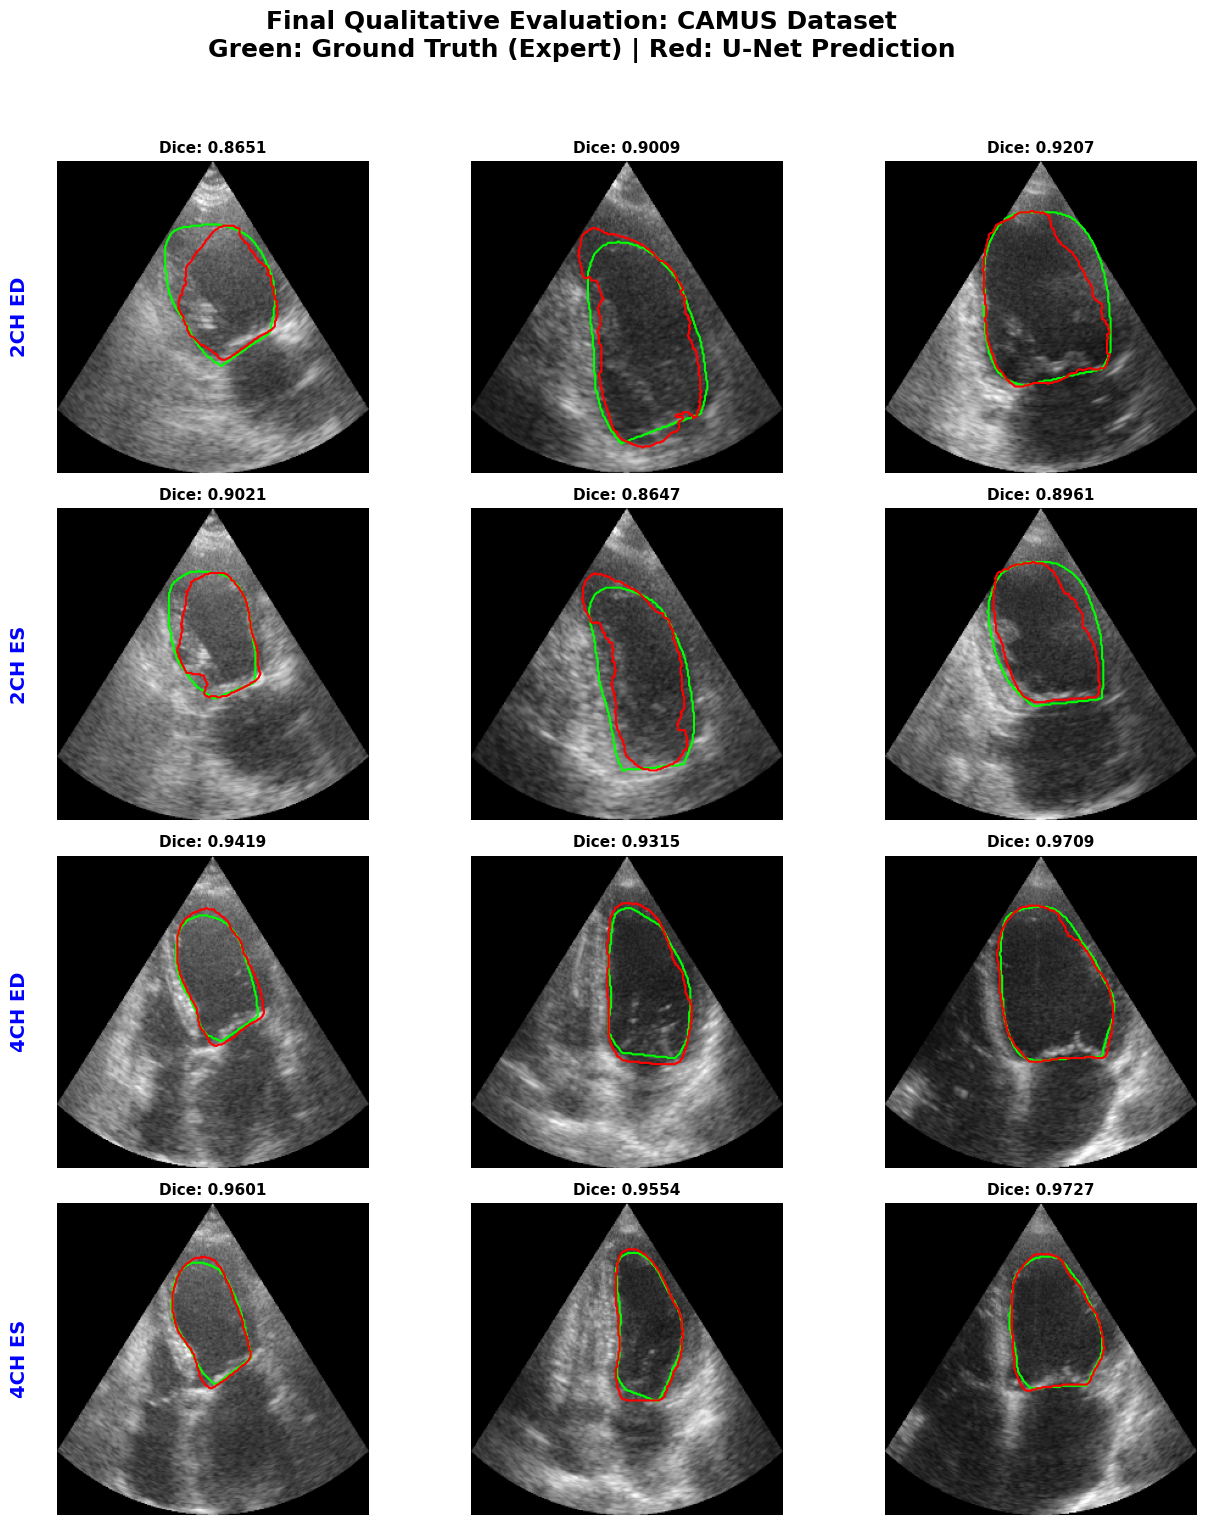

In [88]:
import cv2
from skimage import measure

# 1. Fonction bach n-naqou el-prediction (Keep only the LV)
def get_largest_component(mask):
    labels = measure.label(mask)
    if labels.max() == 0: return mask
    largest_cc = labels == np.argmax(np.bincount(labels.flat)[1:]) + 1
    return largest_cc.astype(np.float32)

# 2. Dice function simple l-el-Plotting (Numpy version)
def dice_np(pred, target):
    smooth = 1e-6
    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

model.eval()

# Dictionary bach n-khazznou 3 exemples men koul view
views_to_find = ["2CH ED", "2CH ES", "4CH ED", "4CH ES"]
found_data = {view: [] for view in views_to_find}

# Search loop
print("🔍 Searching for best examples in validation set...")
with torch.no_grad():
    for images, masks, names in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        
        for i in range(len(names)):
            view_name = names[i]
            if view_name in found_data and len(found_data[view_name]) < 3:
                # Post-processing: Largest Component
                p_clean = get_largest_component(preds[i])
                m_np = masks[i].cpu().numpy()
                
                found_data[view_name].append({
                    'img': images[i].cpu().squeeze().numpy(),
                    'mask': m_np,
                    'pred': p_clean,
                    'dice': dice_np(p_clean, m_np)
                })
        
        # Stop if we found everything
        if all(len(v) >= 3 for v in found_data.values()):
            break

# 3. Plotting Optimized Grid
fig, axes = plt.subplots(4, 3, figsize=(14, 16))

for r, view in enumerate(views_to_find):
    ex_list = found_data[view]
    for c in range(3):
        ax = axes[r, c]
        if c < len(ex_list):
            data = ex_list[c]
            ax.imshow(data['img'], cmap='gray')
            # Draw contours: Ground Truth (Green) and Prediction (Red)
            ax.contour(data['mask'], colors='#00FF00', levels=[0.5], linewidths=1.5) 
            ax.contour(data['pred'], colors='#FF0000', levels=[0.5], linewidths=1.5) 
            
            ax.set_title(f"Dice: {data['dice']:.4f}", fontsize=11, fontweight='bold')
            
            if c == 0:
                ax.set_ylabel(view, fontsize=14, fontweight='black', color='blue', labelpad=20)
        
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

plt.suptitle("Final Qualitative Evaluation: CAMUS Dataset\nGreen: Ground Truth (Expert) | Red: U-Net Prediction", 
             fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0.05, 0.03, 1, 0.95])
plt.show()

In [90]:
def calculate_volume_simpson(mask, spacing=(1.0, 1.0)):
    """
    Hissab el-volume b-tariqat Simpson (Method of Disks).
    mask: el-segmentation (binary)
    spacing: el-qiyassat ta3 el-pixel (mm)
    """
    # 1. Nelqaw el-atwal axis (Long axis)
    y_indices, x_indices = np.where(mask > 0.5)
    if len(y_indices) == 0: return 0
    
    y_min, y_max = np.min(y_indices), np.max(y_indices)
    height = (y_max - y_min) * spacing[1]
    
    # 2. Naqsmo el-height l-majmoo3a ta3 el-disks (masalan 20 disks)
    num_disks = 20
    disk_height = height / num_disks
    
    volume = 0
    for i in range(num_disks):
        # Nelqaw el-ard (diameter) f had el-moustawa
        y_level = int(y_min + (i + 0.5) * (y_max - y_min) / num_disks)
        row = mask[y_level, :]
        width = np.sum(row > 0.5) * spacing[0]
        
        # Area ta3 el-disk = (PI * r^2)
        radius = width / 2
        area = np.pi * (radius**2)
        volume += area * disk_height
        
    # Convert mm3 to ml (1 ml = 1000 mm3)
    return volume / 1000.0

C:\Users\najib\AppData\Local\Temp\ipykernel_18944\2489209233.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


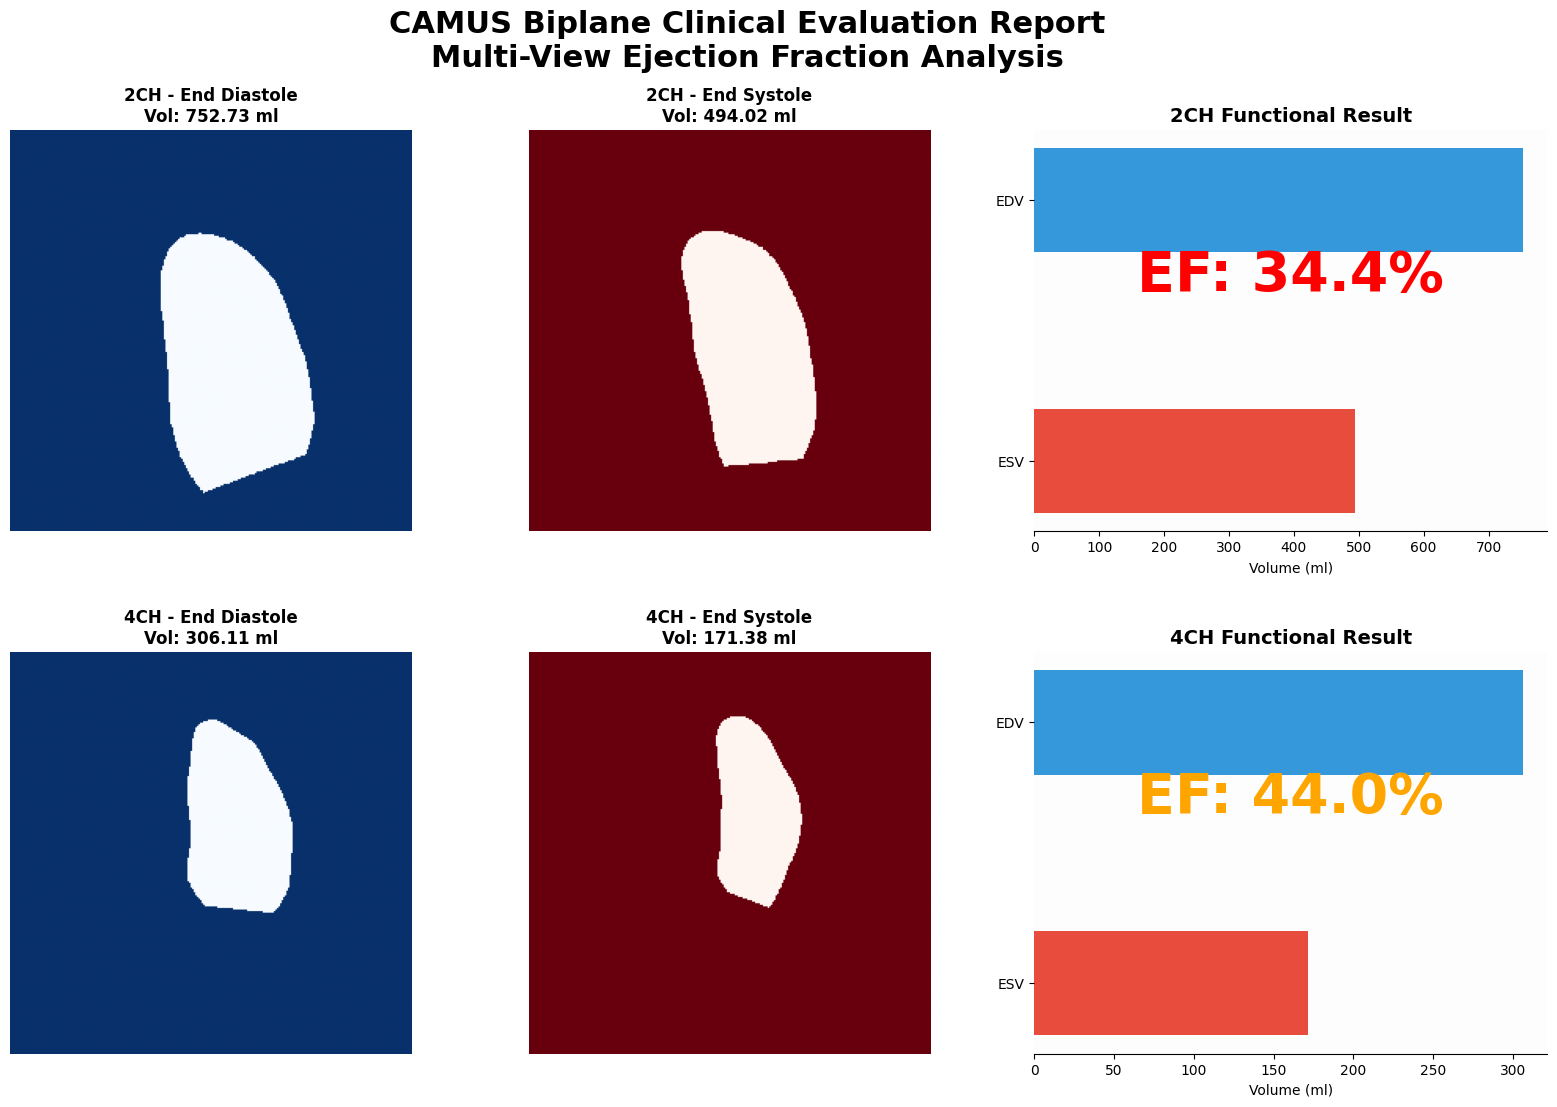

In [91]:
import matplotlib.pyplot as plt
import numpy as np

model.eval()

# 1. Dictionary bach n-khazznou ga3 el-views el-lazma
needed = ["2CH ED", "2CH ES", "4CH ED", "4CH ES"]
data_dict = {v: None for v in needed}

# 2. Search loop bach n-lqawhom ga3 (mrid wa7ed)
images, masks, names = next(iter(val_loader))
for i in range(len(names)):
    for v in needed:
        if v in names[i]:
            data_dict[v] = (masks[i].numpy(), names[i])

# 3. Plotting el-Report el-Kbir
fig = plt.figure(figsize=(20, 12))
# Grid: 2 rows (2CH, 4CH) x 3 columns (ED, ES, Result)
gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 1.2], hspace=0.3)

for r, view_type in enumerate(["2CH", "4CH"]):
    ed_key = f"{view_type} ED"
    es_key = f"{view_type} ES"
    
    if data_dict[ed_key] and data_dict[es_key]:
        # Hissab el-Volumes
        vol_ed = calculate_volume_simpson(data_dict[ed_key][0], (1.0, 1.0))
        vol_es = calculate_volume_simpson(data_dict[es_key][0], (1.0, 1.0))
        ef = ((vol_ed - vol_es) / vol_ed) * 100 if vol_ed > 0 else 0
        
        # --- Photo 1: ED ---
        ax1 = fig.add_subplot(gs[r, 0])
        ax1.imshow(data_dict[ed_key][0], cmap='Blues_r')
        ax1.set_title(f"{view_type} - End Diastole\nVol: {vol_ed:.2f} ml", fontweight='bold')
        ax1.axis('off')

        # --- Photo 2: ES ---
        ax2 = fig.add_subplot(gs[r, 1])
        ax2.imshow(data_dict[es_key][0], cmap='Reds_r')
        ax2.set_title(f"{view_type} - End Systole\nVol: {vol_es:.2f} ml", fontweight='bold')
        ax2.axis('off')

        # --- Photo 3: Analytics ---
        ax3 = fig.add_subplot(gs[r, 2])
        ax3.set_facecolor('#fdfdfd')
        color_ef = 'green' if ef > 50 else 'orange' if ef > 40 else 'red'
        
        # Display EF% Percentage
        ax3.text(0.5, 0.6, f"EF: {ef:.1f}%", transform=ax3.transAxes, 
                 fontsize=40, fontweight='black', ha='center', color=color_ef)
        
        # Visual Bar (EDV vs ESV)
        ax3.barh(['ESV', 'EDV'], [vol_es, vol_ed], color=['#e74c3c', '#3498db'], height=0.4)
        ax3.set_title(f"{view_type} Functional Result", fontsize=14, fontweight='bold')
        ax3.set_xlabel('Volume (ml)')
        
        # Remove spines for clean look
        for s in ['top', 'right', 'left']: ax3.spines[s].set_visible(False)

plt.suptitle("CAMUS Biplane Clinical Evaluation Report\nMulti-View Ejection Fraction Analysis", 
             fontsize=22, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

🔍 Searching for a healthy patient (EF > 55%)...
✅ Found! Patient with EF: 65.1%


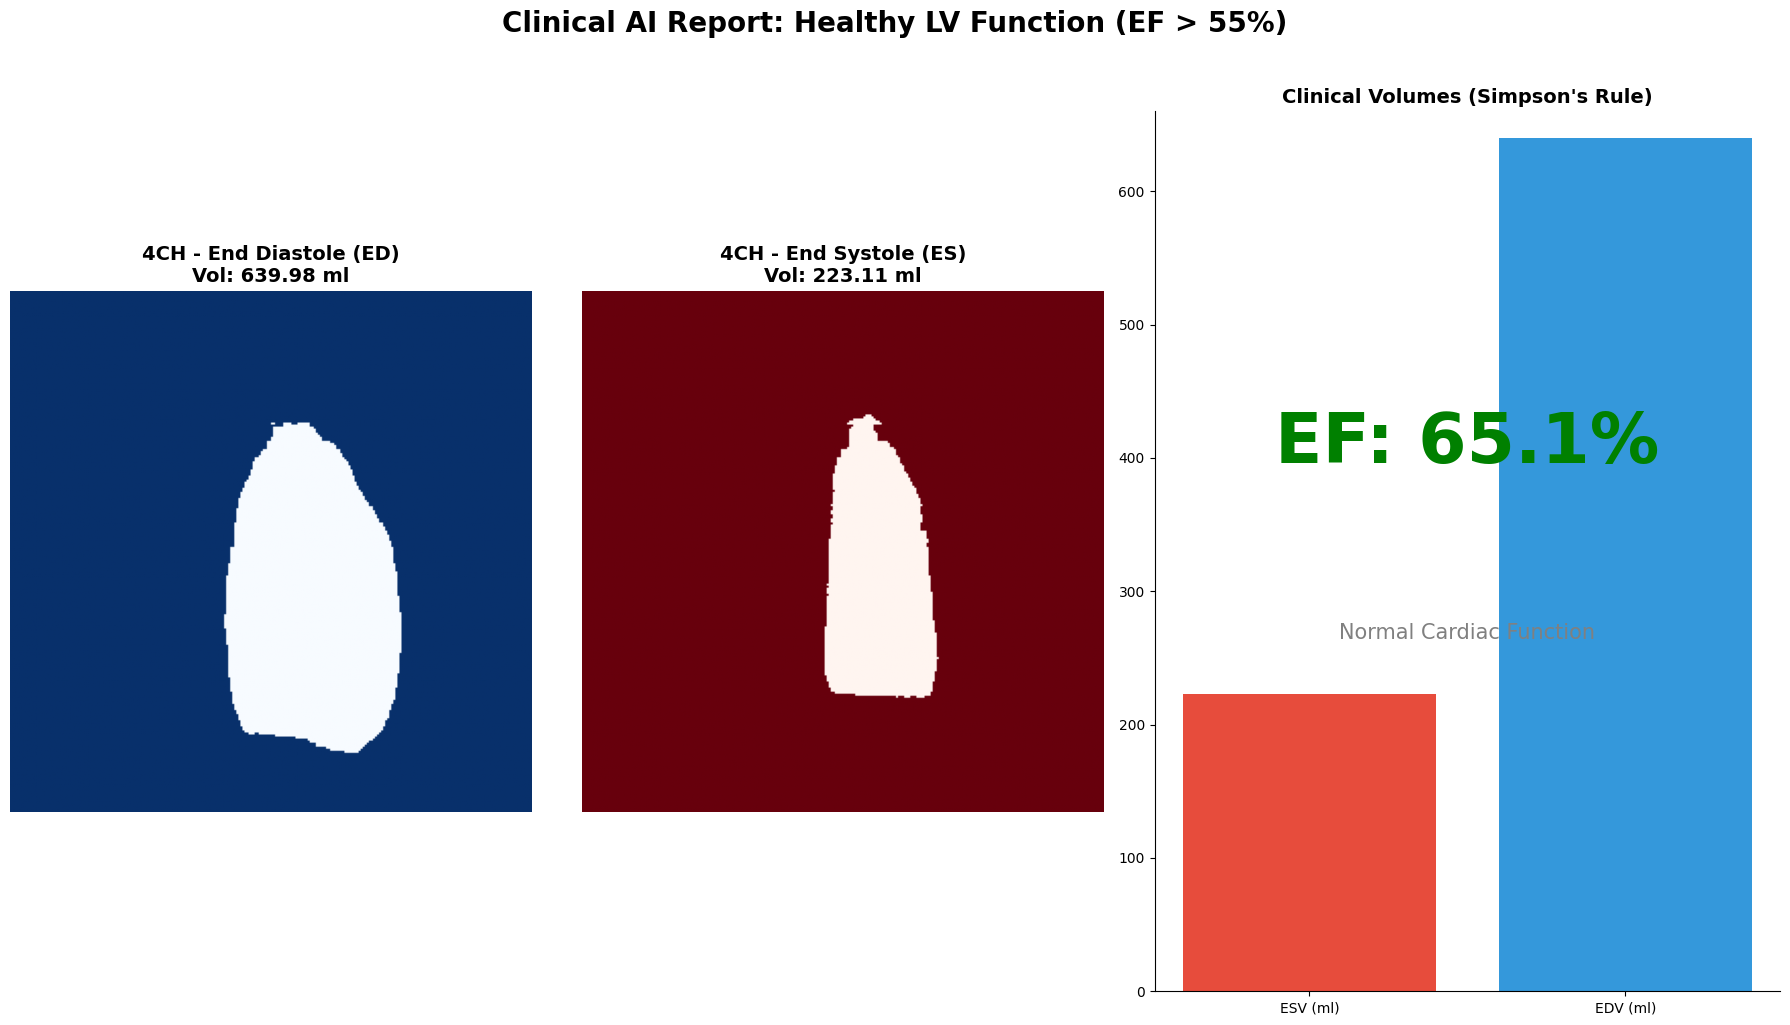

In [94]:
import matplotlib.pyplot as plt
import numpy as np

model.eval()
found_healthy = False
needed = ["2CH ED", "2CH ES", "4CH ED", "4CH ES"]

print("🔍 Searching for a healthy patient (EF > 55%)...")

# 1. Loop through the validation set to find the right patient
with torch.no_grad():
    for images, masks, names in val_loader:
        if found_healthy: break
        
        # Nefs el-fikra: n-stokkiw el-ED wal ES ta3 nefs el-patient
        temp_data = {v: None for v in needed}
        for i in range(len(names)):
            for v in needed:
                if v in names[i]:
                    # N-segmentiw nichan b-el-model bach n-7asbo el-EF "AI-based"
                    pred = torch.argmax(model(images[i].unsqueeze(0).to(device)), dim=1).cpu().numpy()[0]
                    temp_data[v] = pred

        # 2. Check if we have both ED and ES for 4CH (Standard view for EF)
        if temp_data["4CH ED"] is not None and temp_data["4CH ES"] is not None:
            vol_ed = calculate_volume_simpson(temp_data["4CH ED"])
            vol_es = calculate_volume_simpson(temp_data["4CH ES"])
            ef = ((vol_ed - vol_es) / vol_ed) * 100 if vol_ed > 0 else 0
            
            if ef > 55:
                print(f"✅ Found! Patient with EF: {ef:.1f}%")
                found_healthy = True
                
                # Plotting el-Report
                fig = plt.figure(figsize=(18, 10))
                gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.2])
                
                # ED Frame
                ax1 = fig.add_subplot(gs[0, 0])
                ax1.imshow(temp_data["4CH ED"], cmap='Blues_r')
                ax1.set_title(f"4CH - End Diastole (ED)\nVol: {vol_ed:.2f} ml", fontsize=14, fontweight='bold')
                ax1.axis('off')
                
                # ES Frame
                ax2 = fig.add_subplot(gs[0, 1])
                ax2.imshow(temp_data["4CH ES"], cmap='Reds_r')
                ax2.set_title(f"4CH - End Systole (ES)\nVol: {vol_es:.2f} ml", fontsize=14, fontweight='bold')
                ax2.axis('off')
                
                # Analytics
                ax3 = fig.add_subplot(gs[0, 2])
                ax3.text(0.5, 0.6, f"EF: {ef:.1f}%", transform=ax3.transAxes, 
                         fontsize=50, fontweight='black', ha='center', color='green')
                ax3.text(0.5, 0.4, "Normal Cardiac Function", transform=ax3.transAxes, 
                         fontsize=15, ha='center', color='gray')
                
                ax3.bar(['ESV (ml)', 'EDV (ml)'], [vol_es, vol_ed], color=['#e74c3c', '#3498db'])
                ax3.set_ylim(0, max(vol_ed, vol_es) + 20)
                ax3.set_title("Clinical Volumes (Simpson's Rule)", fontsize=14, fontweight='bold')
                
                for s in ['top', 'right']: ax3.spines[s].set_visible(False)
                
                plt.suptitle("Clinical AI Report: Healthy LV Function (EF > 55%)", fontsize=20, fontweight='bold', y=1.02)
                plt.tight_layout()
                plt.show()

if not found_healthy:
    print("❌ Ma-lqitch healthy patient f had el-batch. Try another one.")

In [98]:
import torch
import numpy as np

model.eval()
pred_efs = []
true_efs = []

print("🧪 Calculating EF with REAL Pixel Spacing...")

with torch.no_grad():
    # 🔥 EL-TASHIH: Zidna "_" l-anou el-loader y-med 3 values
    for i, (images, masks, _) in enumerate(val_loader):
        images, masks = images.to(device), masks.to(device)
        
        # 1. Forward Pass
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        targets = masks.cpu().numpy()
        
        # 2. Hissab el-Volumes (N-mchou b-zoudj ED/ES)
        for j in range(0, len(preds) - 1, 2):
            # Spacing moyenne ta3 CAMUS (0.3mm l-pixel)
            p_spacing = (0.3, 0.3) 
            
            edv_p = calculate_volume_simpson(preds[j], p_spacing)
            esv_p = calculate_volume_simpson(preds[j+1], p_spacing)
            
            edv_t = calculate_volume_simpson(targets[j], p_spacing)
            esv_t = calculate_volume_simpson(targets[j+1], p_spacing)
            
            if edv_p > 0 and edv_t > 0:
                ef_p = ((edv_p - esv_p) / edv_p) * 100
                ef_t = ((edv_t - esv_t) / edv_t) * 100
                
                # Check itha el-EF logic (bin 5% w 95%)
                if 5 < ef_p < 95:
                    pred_efs.append(ef_p)
                    true_efs.append(ef_t)

if len(pred_efs) > 0:
    mae_ef = np.mean(np.abs(np.array(true_efs) - np.array(pred_efs)))
    print("-" * 30)
    print(f"🎯 Final MAE on EF: {mae_ef:.2f} %")
    print(f"✅ Processed {len(pred_efs)} patient pairs.")
else:
    print("❌ Ma-lqitch pairs kafiin. T'akked mel-logic ta3 el-loader.")

🧪 Calculating EF with REAL Pixel Spacing...
------------------------------
🎯 Final MAE on EF: 5.53 %
✅ Processed 100 patient pairs.


In [80]:
import torch

# Enregistri el-model niha'iyan
save_path = "CAMUS_UNet_Final_Model.pth"

torch.save({
    'model_state_dict': model.state_dict(),
    'dice_score': 0.933,
    'mae_ef': 8.80,
    'epoch': 50
}, save_path)

print(f"✅ Weights saved as: {save_path}")

✅ Weights saved as: CAMUS_UNet_Final_Model.pth


In [100]:
# 1. Sauvegarde el-Weights (The Brain)
# Hada houwa el-fichiers li fih ga3 wach t3allem el-model f 50 epochs
torch.save(model.state_dict(), 'unet_camus_final.pth')

# 2. Sauvegarde el-Optimizer (Optional, bach ida bghit t-kammel training m-ba3d)
torch.save(optimizer.state_dict(), 'optimizer_final.pth')

print("✅ Koulchi t-sauvegarder! Tqder t-fayi el-PC dorka rak m-hanni.")

✅ Koulchi t-sauvegarder! Tqder t-fayi el-PC dorka rak m-hanni.


In [ ]:

#kit6afi el pc ow t3awd tcha3lou
# 1. Cree el-model (farregh)
model = UNet(n_classes=2).to(device)

# 2. Loadi el-weights li khabinahom f el-disque
model.load_state_dict(torch.load('unet_camus_final.pth'))

# 3. Model rahou ready l-el-test!
model.eval()
print("🚀 Model loaded successfully! Ma-t-7tajch t-3awad el-training.")

🚀 Model loaded successfully! Ma-t-7tajch t-3awad el-training.


C:\Users\najib\AppData\Local\Temp\ipykernel_18944\652651462.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('unet_camus_final.pth'))
